In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\ML_Klasifikasi\Dataset\weather_classification_data.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Kitab Suci\\Fixxxx belajar\\ML_Klasifikasi\\Dataset\\weather_classification_data.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [ ]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
print(df['Weather Type'].value_counts()) 

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


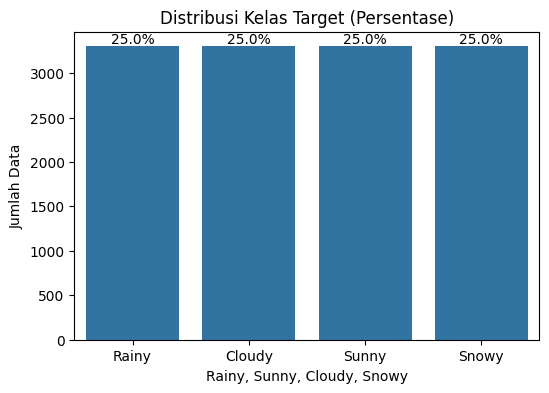

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Weather Type', data=df)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom'
    )

plt.title("Distribusi Kelas Target (Persentase)")
plt.xlabel("Rainy, Sunny, Cloudy, Snowy")
plt.ylabel("Jumlah Data")
plt.show()

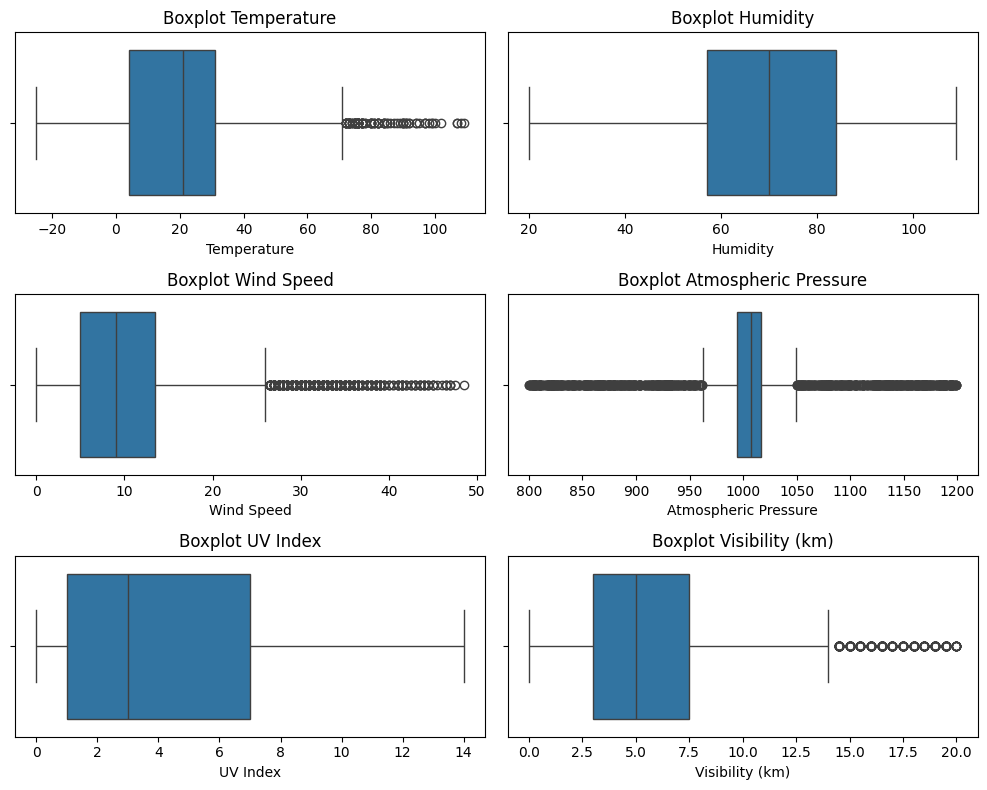

In [ ]:
# Cek outlier
cols = ["Temperature", "Humidity", "Wind Speed","Atmospheric Pressure", "UV Index", "Visibility (km)"]

# buat ukuran figure per grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))  
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
def iqr_capping(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        print(f"{col:25s} → batas [{lower:.1f}, {upper:.1f}] | outlier di-cap: {before}")
    return df_clean

# Hanya kolom yang memiliki outlier
cols_to_cap = ["Temperature", "Wind Speed", "Atmospheric Pressure", "Visibility (km)"]

df_clean = iqr_capping(df, cols_to_cap)

Temperature               → batas [-36.5, 71.5] | outlier di-cap: 92
Wind Speed                → batas [-7.8, 26.2] | outlier di-cap: 404
Atmospheric Pressure      → batas [961.8, 1049.7] | outlier di-cap: 927
Visibility (km)           → batas [-3.8, 14.2] | outlier di-cap: 383


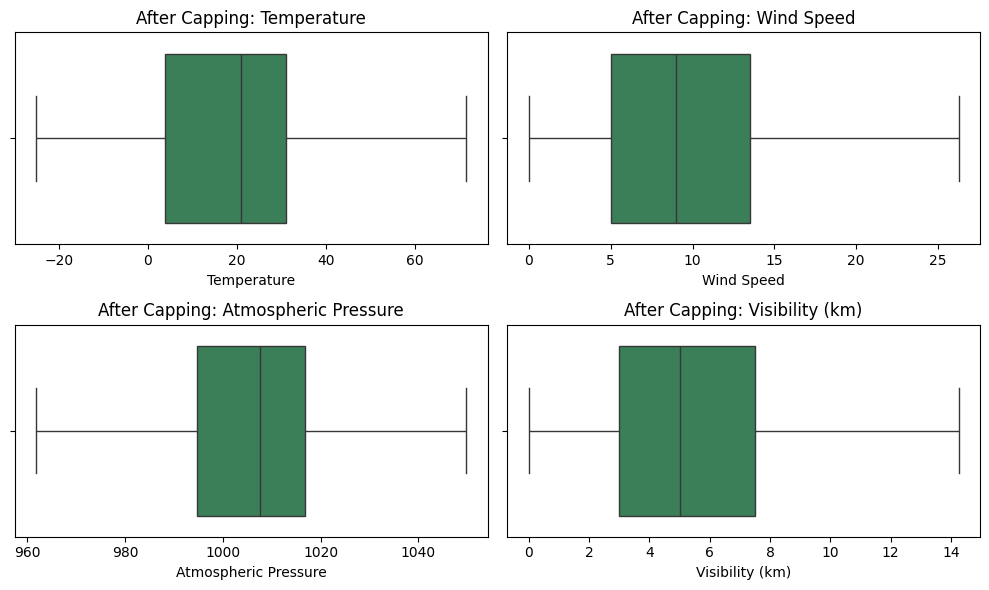

Shape sebelum : (13200, 11)
Shape sesudah : (13200, 11)


In [ ]:
# Cek boxplot ulang
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='seagreen')
    axes[i].set_title(f'After Capping: {col}')

plt.tight_layout()
plt.show()

# Bandingkan shape
print(f"Shape sebelum : {df.shape}")
print(f"Shape sesudah : {df_clean.shape}")  # Harus tetap sama karena capping, bukan drop

In [ ]:
df_model = df_clean.copy()

In [ ]:
cat_cols = ['Cloud Cover', 'Season', 'Location']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model['Weather Type'] = le.fit_transform(df_model['Weather Type'])
df_model.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [ ]:
X = df_model.drop(columns=['Weather Type'])
y = df_model['Weather Type']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah kelas di Y_train: {np.bincount(Y_train)}")
print(f"Jumlah kelas di Y_test: {np.bincount(Y_test)}")


Jumlah kelas di Y_train: [2640 2640 2640 2640]
Jumlah kelas di Y_test: [660 660 660 660]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


=== Logistic Regression Evaluation ===
Accuracy: 0.8602272727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       660
           1       0.85      0.87      0.86       660
           2       0.90      0.92      0.91       660
           3       0.87      0.82      0.84       660

    accuracy                           0.86      2640
   macro avg       0.86      0.86      0.86      2640
weighted avg       0.86      0.86      0.86      2640



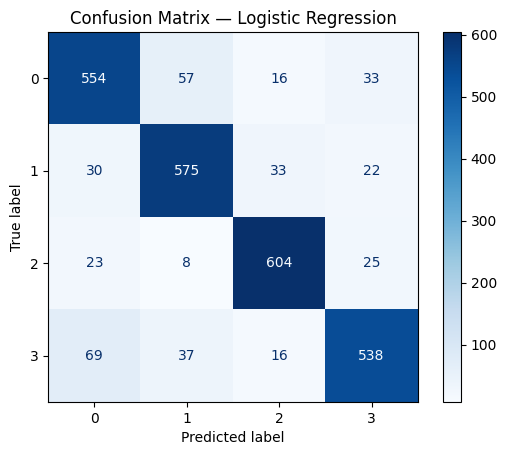

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

y_pred_log = log_model.predict(X_test_scaled)
print("=== Logistic Regression Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

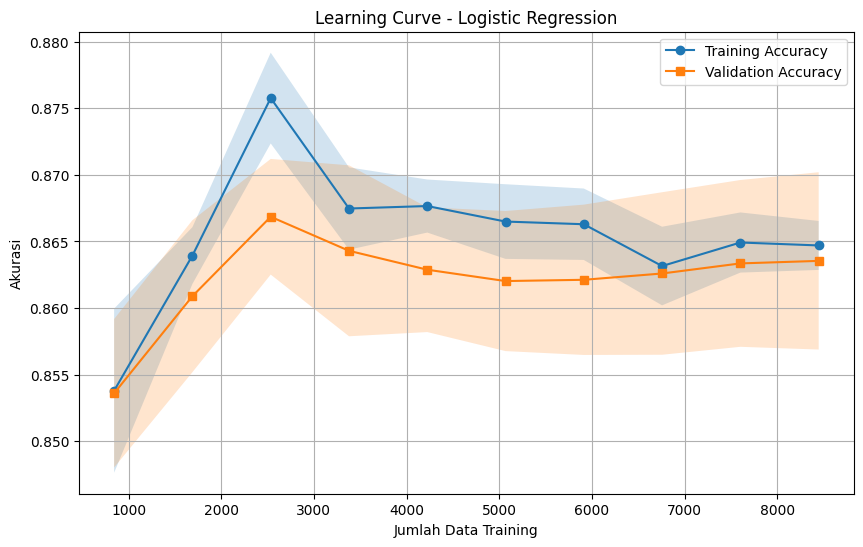

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    log_model,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== KNN Evaluation ===
Accuracy: 0.8996212121212122

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       660
           1       0.87      0.91      0.89       660
           2       0.94      0.91      0.92       660
           3       0.94      0.88      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



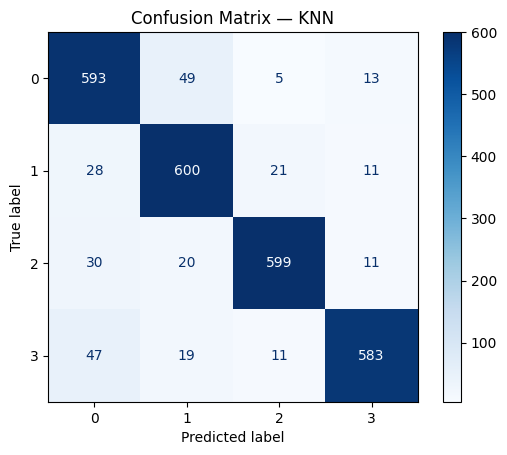

In [ ]:
# KNN
knn_model = KNeighborsClassifier(
    n_neighbors=13,
    metric='minkowski'
)

knn_model.fit(X_train_scaled, Y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=== KNN Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(Y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)
disp_knn.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN")
plt.show()

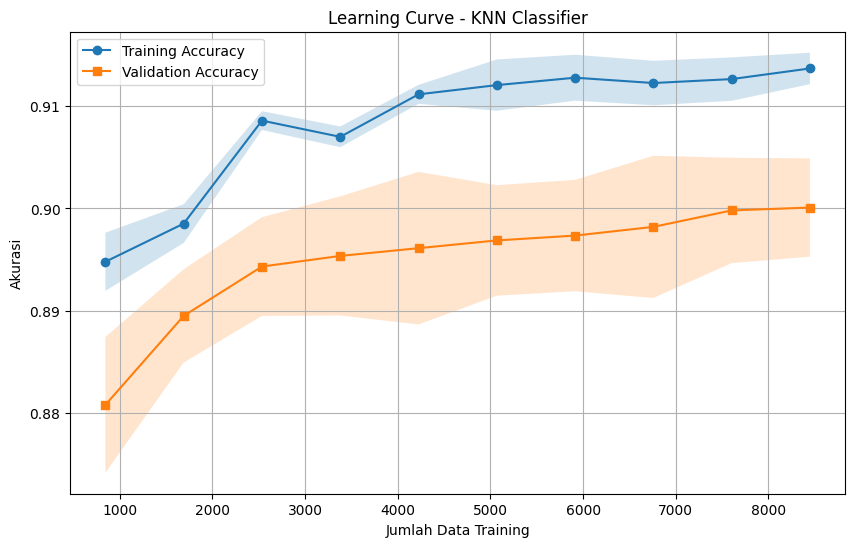

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    knn_model,
    X_train_scaled,  
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Hitung mean dan std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - KNN Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Decision Tree Evaluation ===
Accuracy: 0.8765151515151515

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       660
           1       0.83      0.92      0.87       660
           2       0.95      0.91      0.93       660
           3       0.92      0.81      0.86       660

    accuracy                           0.88      2640
   macro avg       0.88      0.88      0.88      2640
weighted avg       0.88      0.88      0.88      2640



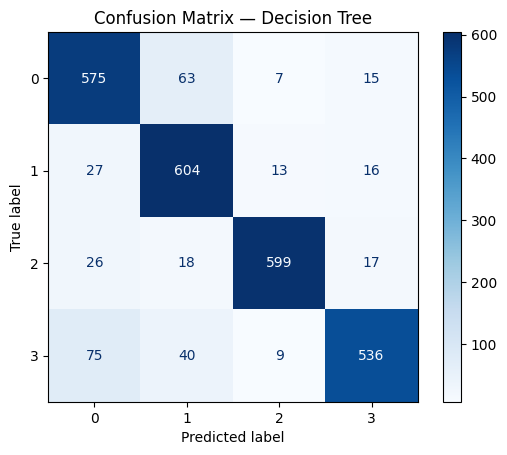

In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, Y_train)


y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_dt))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Decision Tree")
plt.show()

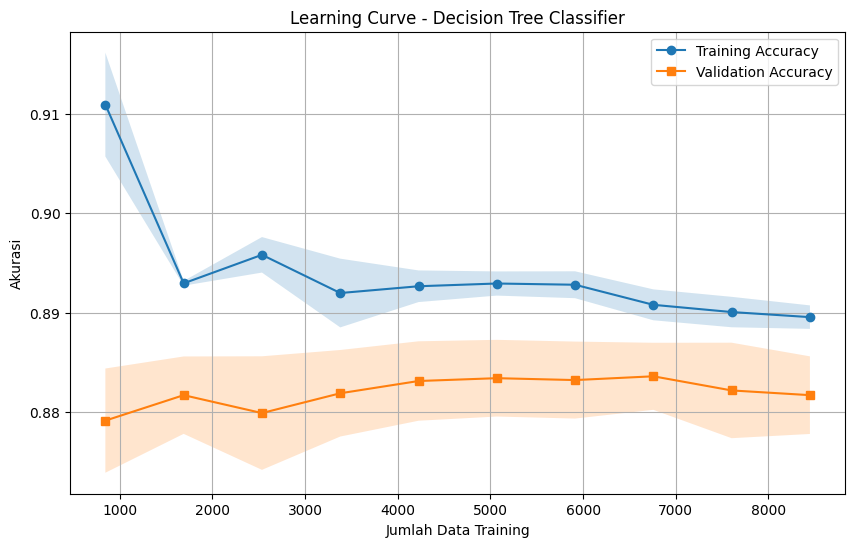

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    dt_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Decision Tree Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Random Forest Evaluation ===
Accuracy: 0.9068181818181819

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       660
           1       0.88      0.92      0.90       660
           2       0.99      0.90      0.94       660
           3       0.94      0.91      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



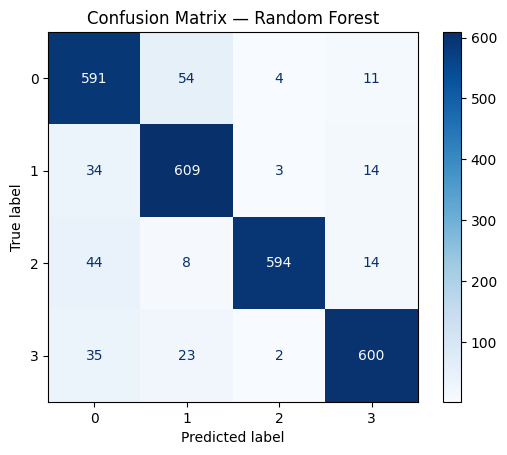

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_split=12,
    min_samples_leaf=8,
    random_state=42
)

rf_model.fit(X_train, Y_train)


y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()

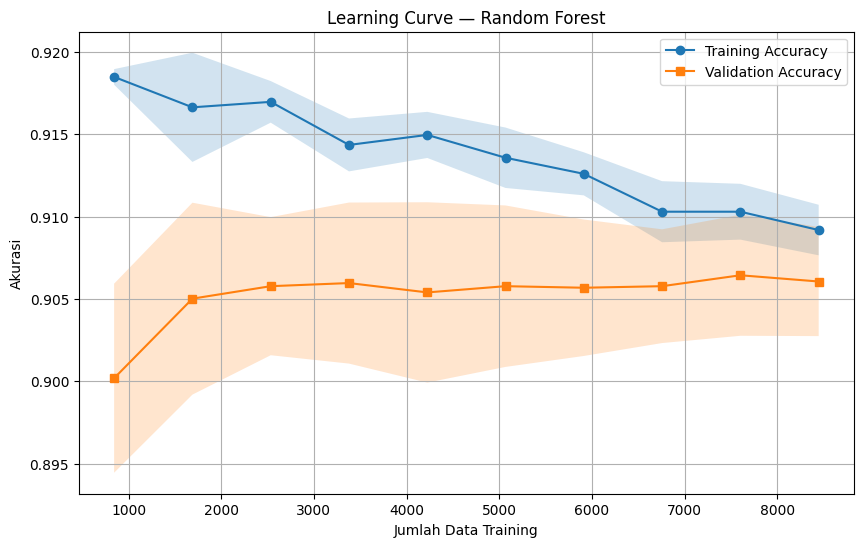

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== XGBoost Evaluation ===
Accuracy: 0.9143939393939394

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       660
           1       0.88      0.93      0.90       660
           2       0.96      0.91      0.93       660
           3       0.95      0.92      0.93       660

    accuracy                           0.91      2640
   macro avg       0.92      0.91      0.91      2640
weighted avg       0.92      0.91      0.91      2640



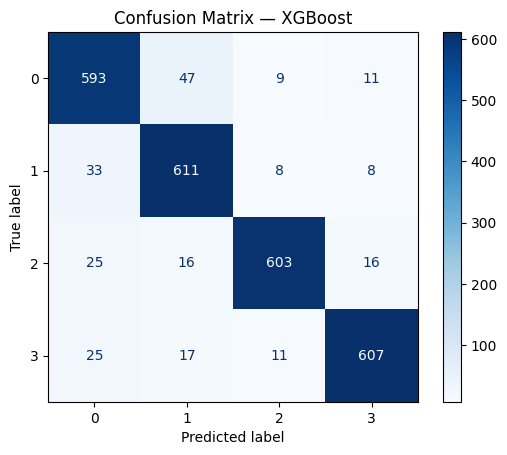

In [ ]:
# xgboost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42
)
xgb_model.fit(X_train, Y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("\nClassification Report:")   
print(classification_report(Y_test, y_pred_xgb))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=xgb_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — XGBoost")
plt.show()

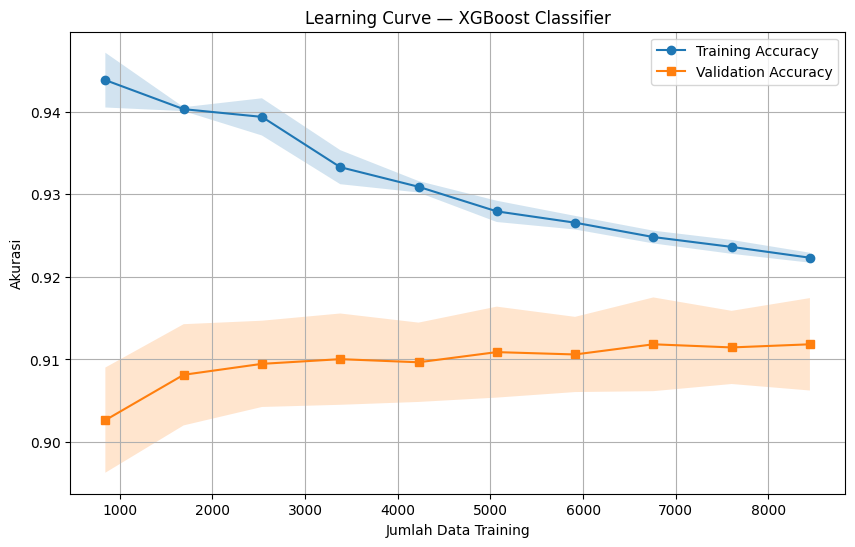

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== SVM Evaluation ===
Accuracy: 0.9106060606060606

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       660
           1       0.90      0.92      0.91       660
           2       0.95      0.91      0.93       660
           3       0.93      0.91      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



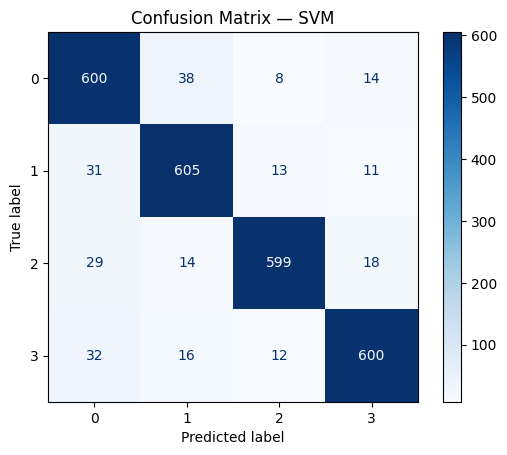

In [ ]:
from sklearn.svm import SVC

# SVM 
svm_model = SVC(
    kernel='rbf',        
    C=1.0,               
    gamma='scale',      
    random_state=42
)

svm_model.fit(X_train_scaled, Y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(Y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)
disp_svm.plot(cmap='Blues')
plt.title("Confusion Matrix — SVM")
plt.show()

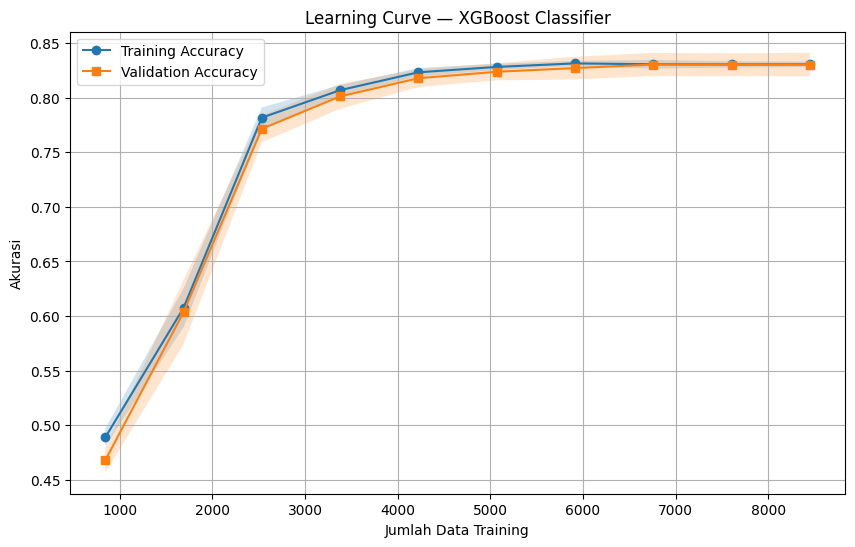

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, Y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy" : accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='weighted'),  # ganti binary → weighted
        "Recall"   : recall_score(Y_test, y_pred, average='weighted'),
        "F1 Score" : f1_score(Y_test, y_pred, average='weighted'),
    }

In [ ]:
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **evaluate_model(log_model, X_test_scaled, Y_test)
})

# KNN
results.append({
    "Model": "KNN",
    **evaluate_model(knn_model, X_test_scaled, Y_test)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    **evaluate_model(dt_model, X_test, Y_test)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    **evaluate_model(rf_model, X_test, Y_test)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    **evaluate_model(xgb_model, X_test, Y_test)
})

# SVM
results.append({
    "Model": "SVM",
    **evaluate_model(svm_model, X_test_scaled, Y_test)
})

In [ ]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860227,0.860563,0.860227,0.860093
1,KNN,0.899621,0.901713,0.899621,0.900074
2,Decision Tree,0.876515,0.880664,0.876515,0.876947
3,Random Forest,0.906818,0.910263,0.906818,0.907633
4,XGBoost,0.914394,0.915638,0.914394,0.914703
5,SVM,0.910606,0.911731,0.910606,0.910874


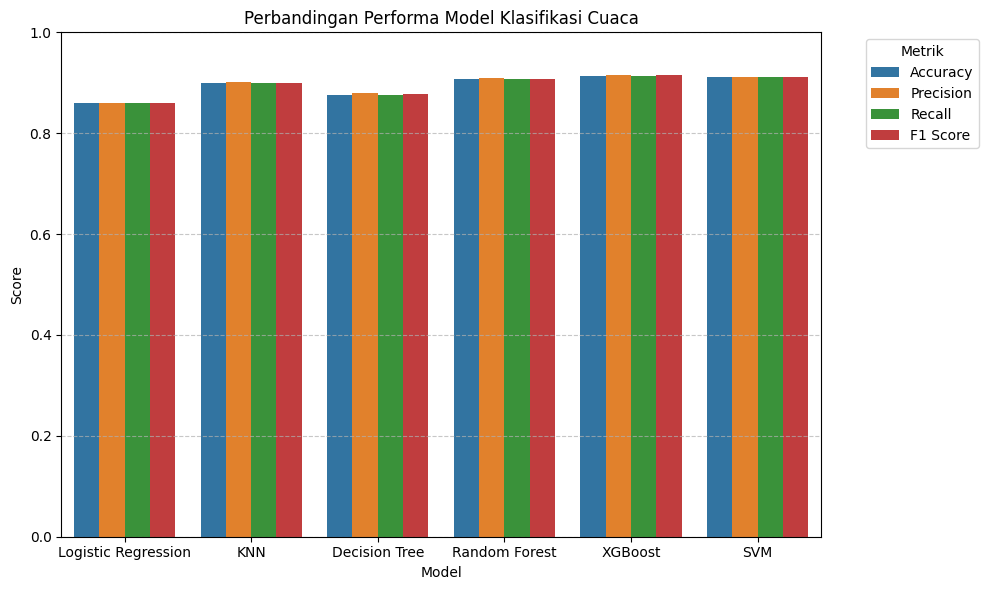

In [ ]:
df_melt = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Perbandingan Performa Model Klasifikasi Cuaca")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metrik", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()